Import package

In [13]:
!pip install deepxde
#%matplotlib ipympl
import numpy as np
import deepxde as dde
import torch
from mpl_toolkits.mplot3d import Axes3D
dde.backend.set_default_backend('pytorch')
import matplotlib.pyplot as plt


Setting the default backend to "pytorch". You can change it in the ~/.deepxde/config.json file or export the DDE_BACKEND environment variable. Valid options are: tensorflow.compat.v1, tensorflow, pytorch, jax, paddle (all lowercase)


In [14]:
#matplotlib.get_backend()

Setting PDE

In [15]:
c=1
def pde(x,y):
    d2y_dx2=dde.grad.hessian(y,x,i=0,j=0)
    d2y_dt2=dde.grad.hessian(y,x,i=1,j=1)
    return d2y_dx2-c**2*d2y_dt2

Setting exact solution

In [16]:
A=2
def func(x):
    x, t=np.split(x,2,axis=1)
    return np.sin(np.pi*x)*np.cos(c*np.pi*t)+np.sin(A*np.pi*x)*np.cos(A*c*np.pi*t)

Defining domain

In [17]:
geom=dde.geometry.Interval(0,1)
timedomain=dde.geometry.TimeDomain(0,1)
geomtime=dde.geometry.GeometryXTime(geom,timedomain)

Setting boundary condition and initial condition

In [18]:
bc=dde.icbc.DirichletBC(geomtime, func, lambda _,on_boundary: on_boundary)
ic_1=dde.icbc.IC(geomtime, func, lambda _, on_boundary: on_boundary)
ic_2=dde.icbc.OperatorBC(geomtime, lambda x, y, _ : dde.grad.jacobian(y, x, i=0, j=1), 
                         lambda x,_ : dde.utils.isclose(x[1],0))

Construct PDE data

In [19]:
'''Homework!!! Setting the point of training'''
data=dde.data.TimePDE(geomtime, pde, [bc, ic_1, ic_2], num_domain=XXX, num_boundary=XXX, num_initial=XXXX, solution=func, num_test=XXXX)
#All the value are suggest range from 100~1000

Construct Neural Network

In [20]:
'''Homework!!! Setting layer size'''
'''Homework!!! Adding hidden layer and different width of layer'''
layer_size=[2]+[XXXX]*XX+[1] #first XXXX is the width of neural, second XX is layer of hidden layer 
activation='tanh'
initializer='Glorot uniform'
net=dde.nn.FNN(layer_size, activation, initializer)

Construct model

In [21]:
'''Homework!!! Setting learning rate'''
model=dde.Model(data,net)
model.compile('adam', lr=XXXX) #suggest range 1e-4~1e-2

Compiling model...
'compile' took 0.000334 s



Training model!

In [22]:
'''Homework!!! Setting iteration(number of training) '''
losshistory, train_state=model.train(iterations=XXXXX) #suggest range 1000~50000

Training model...

Step      Train loss                                  Test loss                                   Test metric
0         [1.12e-03, 3.12e-02, 9.57e-01, 3.02e-03]    [1.40e-03, 3.12e-02, 9.57e-01, 3.02e-03]    []  
1000      [8.48e-04, 3.68e-02, 3.27e-02, 9.88e-04]    [1.20e-03, 3.68e-02, 3.27e-02, 9.88e-04]    []  

Best model at step 1000:
  train loss: 7.14e-02
  test loss: 7.17e-02
  test metric: []

'train' took 10.919419 s



Saving loss history to C:\Users\pcgm6\113人工智慧\HW5\loss.dat ...
Saving training data to C:\Users\pcgm6\113人工智慧\HW5\train.dat ...
Saving test data to C:\Users\pcgm6\113人工智慧\HW5\test.dat ...


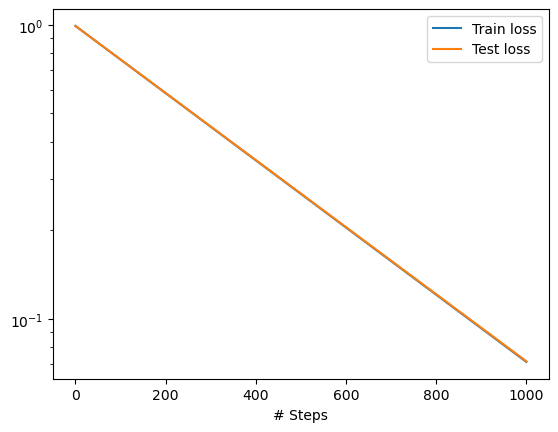

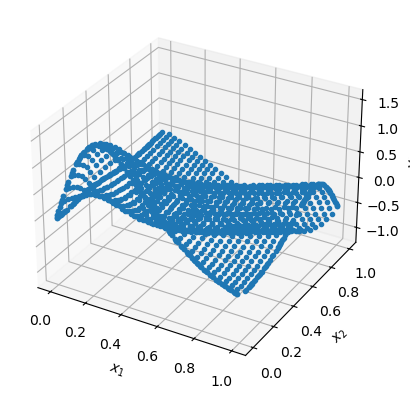

In [23]:
dde.saveplot(losshistory, train_state, issave=True, isplot=True)
plt.xlabel('x')
plt.ylabel('t')

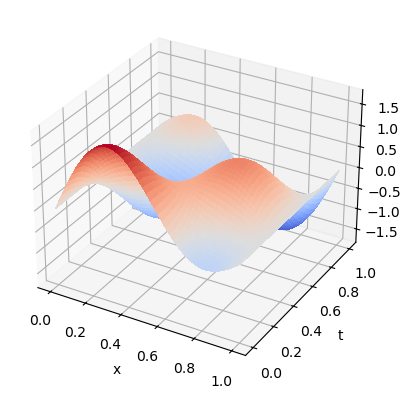

In [24]:
#x=np.linspace(0,1,10)
#x=x[:,np.newaxis]
#y=np.linspace(0,1,10)
#y=y[:,np.newaxis]
#x1=np.concatenate((x,y), axis=1)
#%matplotlib notebook
x, t=np.meshgrid(np.linspace(0,1,100), np.linspace(0,1,100))
Z=np.sin(np.pi*x)*np.cos(c*np.pi*t)+np.sin(A*np.pi*x)*np.cos(A*c*np.pi*t)
fig=plt.figure()
ax=fig.add_subplot(111,projection='3d')
ax.plot_surface(x,t,Z, rstride=2, cstride=2, cmap=plt.get_cmap('coolwarm'), edgecolor='gray', linewidth=0.5)
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_zlabel('E')
#ax.colorbar()
plt.show()